<img src="https://images.pexels.com/photos/848612/pexels-photo-848612.jpeg" />

# Ski Resort Analytics ⛷️

You work as a **AI analyst at AlpineTrack**, a company that runs three ski resorts in the French Alps. The operations team needs visual reports to plan staffing, set prices, and schedule lift maintenance. The board reads these reports every month before approving budgets.

Download from **resources** the four CSV files that accompany this notebook. Place them in the same folder before running the cells.
- `alpinetrack_daily.csv`: 120 days of operations data: visitors, temperature, snowfall, next-day visitors.
- `alpinetrack_lifts.csv`: total passengers per lift over the season.
- `alpinetrack_revenue.csv`: revenue by source for the season.
- `alpinetrack_wait_times.csv`: 100 peak-hour wait time samples per lift.

## Setup

### Instructions

In the next code cell, do the following:

1. Import `matplotlib.pyplot` and give it the conventional alias `plt`.
2. Import `numpy` and give it the conventional alias `np`.
3. Import `pandas` and give it the conventional alias `pd`.
4. Configure three global Matplotlib defaults using `plt.rcParams` so every chart in this notebook shares the same look:
   - Set `"figure.figsize"` to `(10, 6)` (width, height in inches).
   - Set `"axes.grid"` to `True` so a grid is drawn on every chart.
   - Set `"grid.alpha"` to `0.3` so the grid is visible but discreet.

<Note type='tip'>
**Why `rcParams`?** `rcParams` is Matplotlib's runtime configuration dictionary. Setting values here once means every later `plt.figure(...)` and every Axes inherits them. You can still override per chart when you need to.
</Note>


In [47]:
# your code here
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3




## Load the datasets

### Instructions

The CSV files are stored in a folder named `src/` next to this notebook. In the next code cell:

1. Use `pd.read_csv(...)` to load each of the four CSV files into its own DataFrame:
   - Load `src/alpinetrack_daily.csv` into a variable named `daily_df`.
   - Load `src/alpinetrack_lifts.csv` into a variable named `lifts_df`.
   - Load `src/alpinetrack_revenue.csv` into a variable named `revenue_df`.
   - Load `src/alpinetrack_wait_times.csv` into a variable named `waits_df`.
2. Convert the `date` column of `daily_df` from text to a real datetime using `pd.to_datetime(...)`. Reassign the result back to `daily_df["date"]`.
3. Print the number of rows in each DataFrame using `len(...)` and an f-string. Print one line per DataFrame in this order: daily, lifts, revenue, wait time.
4. As the **last** expression in the cell, write `daily_df.head()` (without `print(...)`). Jupyter will render the first five rows as a nicely formatted table so you can sanity-check the load.

<Note type='tip'>
**Why convert the date column?** Without `pd.to_datetime`, the `date` column is stored as plain strings. Matplotlib would treat it as categorical labels and the time axis would be wrong (no proper spacing between days, no month ticks). Converting once at load time fixes every chart that uses that column later.
</Note>


In [48]:
# your code here
import pandas as pd
daily_df = pd.read_csv("src/alpinetrack_daily.csv")
lifts_df = pd.read_csv("src/alpinetrack_lifts.csv")
revenue_df = pd.read_csv("src/alpinetrack_revenue.csv")
waits_df = pd.read_csv("src/alpinetrack_wait_times.csv")

daily_df['date'] = pd.to_datetime(daily_df['date'])

print(f"Numbers rows in daily {len(daily_df)}")
print(f"Numbers rows in lifts {len(lifts_df)}")
print(f"Numbers rows in revenue {len(revenue_df)}")
print(f"Numbers rows in waits {len(waits_df)}")

daily_df.head()

Numbers rows in daily 120
Numbers rows in lifts 5
Numbers rows in revenue 5
Numbers rows in waits 500


,date,visitors,temperature_celsius,snowfall_cm,next_day_visitors
0,2024-12-01,902,-7.2,28.9,1682
1,2024-12-02,1235,-2.4,11.2,1292
2,2024-12-03,1070,2.9,1.0,1154
3,2024-12-04,906,2.0,25.8,1670
4,2024-12-05,871,5.5,7.1,798


## Task 1: Track daily visitors with a line plot

The operations team wants to see how attendance changes from December through March. Peak days need more lift operators and rental staff. Quiet days need fewer.

A **line plot** is the right tool here. It shows how a number changes over time. Spikes and dips are obvious at a glance. The data already includes the Christmas vacation peak and the February school vacation peak.

### Instructions

In the next code cell, build a single line chart of daily visitors over time:

1. Open a new figure with `plt.figure(figsize=(12, 6))`. This chart needs to be wider than the default because the x-axis spans four months of dates.
2. Call `plt.plot(...)` with three things:
   - The dates on the x-axis: `daily_df["date"]`.
   - The visitor counts on the y-axis: `daily_df["visitors"]`.
   - Style the line with `color="steelblue"` and `linewidth=1.5`.
3. Add a title with `plt.title(...)`. Use the text `"Daily Visitor Count - Winter Season 2024"`, with `fontsize=16` and `fontweight="bold"`.
4. Add axis labels:
   - x-axis: `"Date"` with `fontsize=12`.
   - y-axis: `"Number of Visitors"` with `fontsize=12`.
5. Rotate the x-axis tick labels 45 degrees with `plt.xticks(rotation=45)` so the dates do not overlap.
6. Call `plt.tight_layout()` to keep the rotated labels from being clipped.
7. Call `plt.show()` to render the chart.


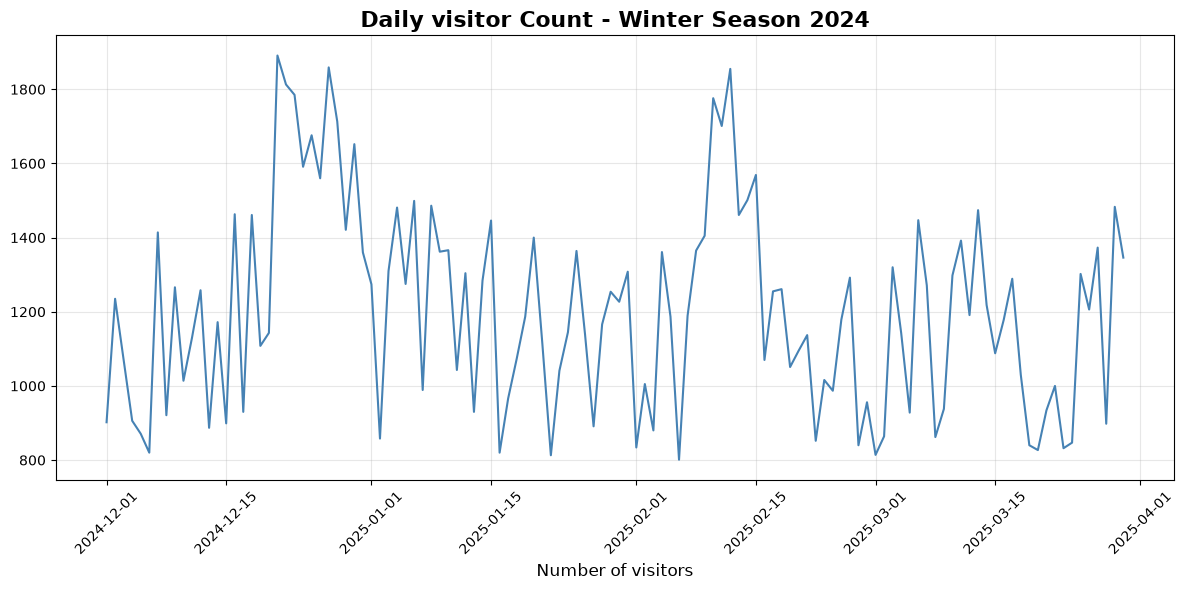

In [49]:
# your code here
plt.figure(figsize=(12, 6))
plt.plot(daily_df["date"], daily_df["visitors"], color="steelblue", linewidth=1.5)
plt.title("Daily visitor Count - Winter Season 2024", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.xlabel("Number of visitors", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [50]:

import plotly.express as px

fig = px.line(
    daily_df, x="date", y="visitors",
    title="Daily visitors Count - Winter Season 2024"
)

fig.show()

## Task 2: Compare lift usage with a horizontal bar chart

The resort runs five main lifts. Some carry many more passengers than others. The maintenance team wants to know which lifts to service first. Heavy-use lifts wear out faster and need more attention.

A **horizontal bar chart** works well when category names are long. The names sit on the y-axis where they have room to breathe. The bars run left to right so the eye reads the lengths quickly.

### Instructions

In the next code cell:

1. Sort the `lifts_df` DataFrame by the `total_passengers` column in **ascending** order using `sort_values("total_passengers", ascending=True)`. Store the result in a new variable called `sorted_lifts`.
2. Define a list of five hex color codes called `bar_colors` so each bar has its own color. Use these values in this order: `"#9467bd"`, `"#d62728"`, `"#2ca02c"`, `"#ff7f0e"`, `"#1f77b4"`.
3. Open a new figure with `plt.figure(figsize=(10, 6))`.
4. Call `plt.barh(...)` with:
   - The lift names on the y-axis: `sorted_lifts["lift_name"]`.
   - The passenger totals as bar lengths: `sorted_lifts["total_passengers"]`.
   - The color list: `color=bar_colors`.
5. Add a title `"Total Passengers by Lift - Season 2024"` with `fontsize=16` and `fontweight="bold"`.
6. Label the x-axis `"Total Passengers"` and the y-axis `"Lift Name"`, both with `fontsize=12`.
7. Finish with `plt.tight_layout()` and `plt.show()`.

<Note type='tip'>
**Why sort ascending?** A horizontal bar chart draws the **first** row at the bottom and the **last** row at the top. Sorting ascending in step 1 puts the largest bar at the top, which is how readers expect to see ranked data.
</Note>


In [51]:
# your code here
sorted_lifts_df = lifts_df.sort_values("total_passengers", ascending=True)
bar_colors = ["#9467bd", "#d62728", "#2ca02c", "#ff7f0e"]

fig = px.bar(
    sorted_lifts_df, x="lift_name", y="total_passengers",
    orientation="h",
    color="total_passengers",
    color_continuous_scale="Blues",
    labels={
            "lift_name": "Remontées",
            "total_passengers": "nb passager"
        },
    title="Total Passengers by Lift - Season 2024"
)

fig.show()

## Task 3: Break down revenue with a pie chart

The finance team needs to know where the money comes from. Resort revenue splits into five sources: lift tickets, equipment rentals, ski school, food and beverage, and retail.

A **pie chart** shows proportions. It answers the question "what share of the whole?" at a glance. Use the `explode` parameter to pull the most important slice slightly outward. This draws the eye to the headline finding.

### Instructions

In the next code cell:

1. Define a list of five hex color codes called `slice_colors` for the pie slices. Use these values in this order: `"#3D4A5C"`, `"#A8C5DD"`, `"#E8B04E"`, `"#7FA15A"`, `"#C97A57"`.
2. Define a tuple called `explode_settings` with five values. Set the **first** value to `0.1` and all others to `0`. This pulls the first slice (lift tickets, the largest source) slightly out of the pie. The tuple must be `(0.1, 0, 0, 0, 0)`.
3. Open a new figure with `plt.figure(figsize=(10, 8))`. A pie chart looks better when it is closer to square.
4. Call `plt.pie(...)` with the following arguments:
   - The slice values: `revenue_df["amount_eur"]`.
   - The slice labels: `labels=revenue_df["source"]`.
   - `autopct="%1.1f%%"` to show each percentage with one decimal place (e.g., `44.0%`).
   - `startangle=90` so the first slice starts pointing straight up.
   - `colors=slice_colors`.
   - `explode=explode_settings`.
   - `shadow=True` to add a subtle drop shadow.
5. Add a title `"Revenue Distribution by Source - Season 2024"` with `fontsize=16` and `fontweight="bold"`.
6. Finish with `plt.tight_layout()` and `plt.show()`.


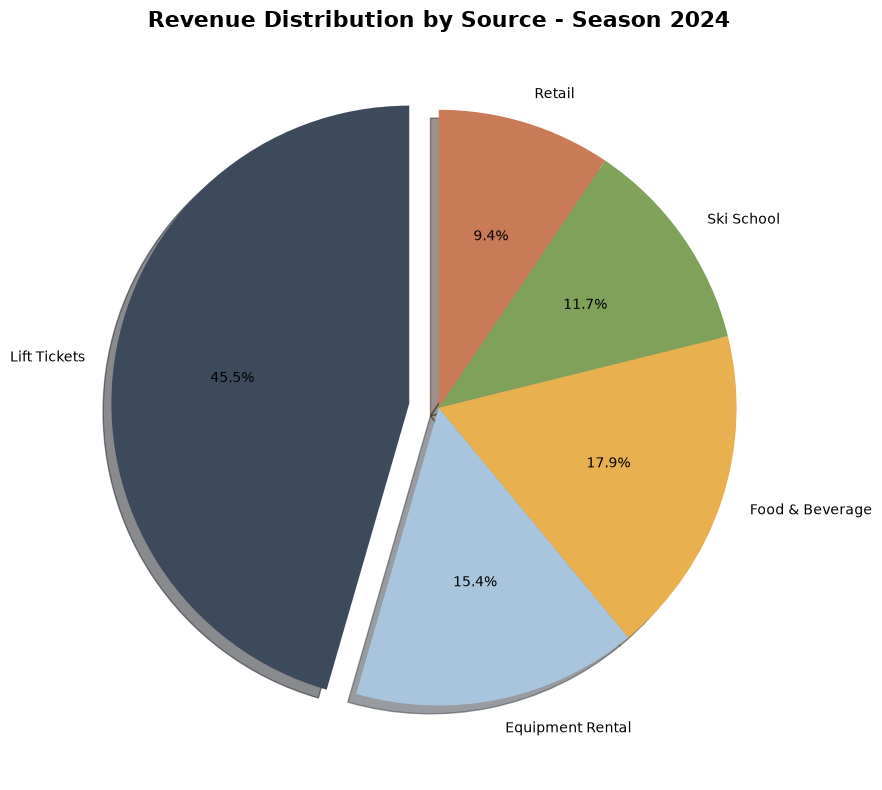

In [52]:
# your code here
slice_colors = ["#3D4A5C", "#A8C5DD", "#E8B04E", "#7FA15A", "#C97A57"]

# 2. 
explode_settings = (0.1, 0, 0, 0, 0)
plt.figure(figsize=(10, 8))
plt.pie(
    revenue_df["amount_eur"],
    labels=revenue_df["source"],
    autopct="%1.1f%%",
    startangle=90,
    colors=slice_colors,
    explode=explode_settings,
    shadow=True,
)

plt.title("Revenue Distribution by Source - Season 2024", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()


## Task 4: Analyze temperature with a histogram

Weather drives ski operations. The daily dataset includes the high temperature for each day. Now the team needs to know the typical range and spot warm days that hurt snow quality.

A **histogram** shows the distribution of a numeric variable. It groups values into bins and shows how many days fall into each bin. Add a vertical line at the mean to give the reader a quick reference point.

### Instructions

In the next code cell:

1. Compute the mean of the `temperature_celsius` column from `daily_df` using `.mean()`. Store the result in a variable called `mean_temperature`.
2. Open a new figure with `plt.figure(figsize=(10, 6))`.
3. Call `plt.hist(...)` to draw the histogram:
   - Use the data `daily_df["temperature_celsius"]`.
   - Set `bins=25` so the values are grouped into 25 equal-width buckets.
   - Style with `color="#A8C5DD"`, `alpha=0.8` (slightly transparent), and `edgecolor="black"` so each bar has a visible outline.
4. Build a label string for the mean line. Use an f-string with one decimal place:
   ```python
   mean_label = f"Mean = {mean_temperature:.1f} degrees C"
   ```
5. Add a vertical line at the mean with `plt.axvline(...)`. Pass:
   - The position: `mean_temperature`.
   - `color="red"`, `linestyle="--"`, `linewidth=2`.
   - `label=mean_label` so the legend can pick it up.
6. Add a title `"Daily High Temperature Distribution - Winter Season"` with `fontsize=16` and `fontweight="bold"`.
7. Label the x-axis `"Temperature (degrees C)"` and the y-axis `"Number of Days"`, both with `fontsize=12`.
8. Call `plt.legend()` to display the legend (this is what makes the mean label show up on the chart).
9. Finish with `plt.tight_layout()` and `plt.show()`.


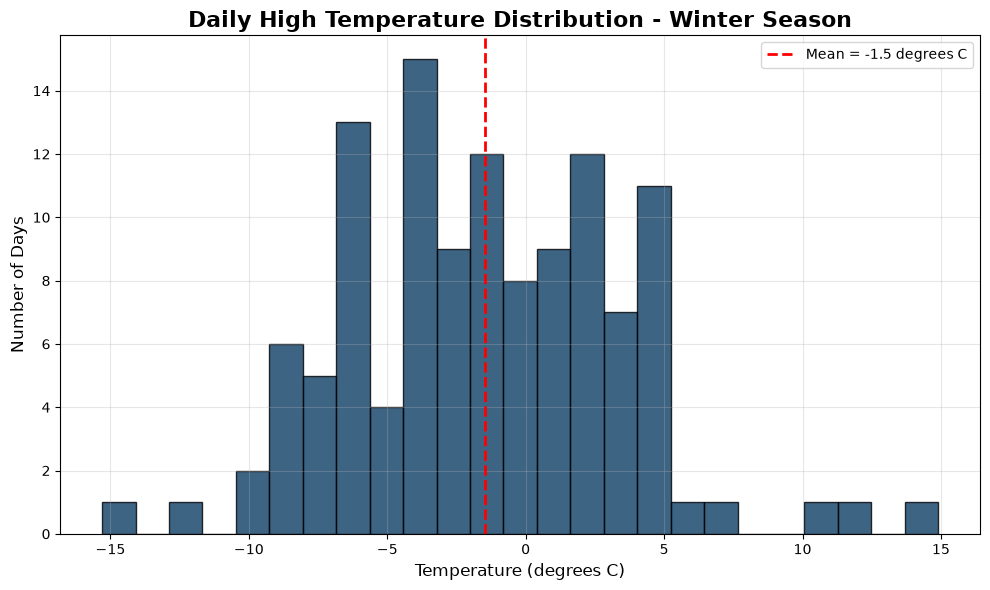

In [53]:
# your code here


mean_temperature = daily_df["temperature_celsius"].mean()
plt.figure(figsize=(10, 6))

plt.hist(
    daily_df["temperature_celsius"],
    bins=25,
    color="#0D3D65",
    alpha=0.8,
    edgecolor="black",
)

mean_label = f"Mean = {mean_temperature:.1f} degrees C"

# 5. 
plt.axvline(
    mean_temperature,
    color="red",
    linestyle="--",
    linewidth=2,
    label=mean_label,
)

# 6.
plt.title("Daily High Temperature Distribution - Winter Season", fontsize=16, fontweight="bold")

plt.xlabel("Temperature (degrees C)", fontsize=12)
plt.ylabel("Number of Days", fontsize=12)

plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Compare wait times across lifts with a boxplot

Guest satisfaction depends on how long people wait at lifts. The wait times CSV contains 100 peak-hour samples per lift. The team wants to see which lifts have the worst waits and which are reliable.

A **boxplot** is the right tool when you compare distributions across categories. Each box shows the median, the middle 50% of values, and the typical range. Outliers appear as dots. One chart compares all five lifts side by side.

The wait times data is in **long format**: one row per measurement, with a `lift_name` column. To feed Matplotlib's boxplot, group the values by lift and pass each group as a separate series.

### Instructions

In the next code cell:

1. Define a list called `lift_order` that fixes the left-to-right order of the boxes on the chart:
   `["Summit Express", "Alpine Quad", "Glacier Lift", "Beginner Tow", "Valley Chair"]`.

2. Build a list called `all_wait_times` containing one NumPy array per lift, in the same order as `lift_order`:
   - Start with an empty list: `all_wait_times = []`.
   - Loop over each `lift_name` in `lift_order`.
   - Inside the loop, filter `waits_df` to the rows where `lift_name` matches: `lift_rows = waits_df[waits_df["lift_name"] == lift_name]`.
   - Pull out the `wait_minutes` values as a NumPy array with `.values`.
   - Append that array to `all_wait_times`.

3. Define a list called `lift_labels` with line breaks (`\n`) inside each name so the x-axis labels do not overlap:
   `["Summit\nExpress", "Alpine\nQuad", "Glacier\nLift", "Beginner\nTow", "Valley\nChair"]`.

4. Open a new figure with `plt.figure(figsize=(12, 6))`.

5. Call `plt.boxplot(...)` and assign the result to a variable called `box_plot`:
   - First argument: `all_wait_times`.
   - `tick_labels=lift_labels` to label each box.
   - `patch_artist=True` so the boxes can be filled with color (without this, only the outlines can be styled).

6. Define a list of five hex color codes called `box_colors`: `"#3D4A5C"`, `"#A8C5DD"`, `"#E8B04E"`, `"#7FA15A"`, `"#C97A57"`.

7. Loop with `zip(box_plot["boxes"], box_colors)` and for each pair call `patch.set_facecolor(color)` to paint each box.

8. Add a title `"Lift Wait Time Distribution (Peak Hours)"` with `fontsize=16` and `fontweight="bold"`.

9. Label the x-axis `"Lift"` and the y-axis `"Wait Time (minutes)"`, both with `fontsize=12`.

10. Finish with `plt.tight_layout()` and `plt.show()`.


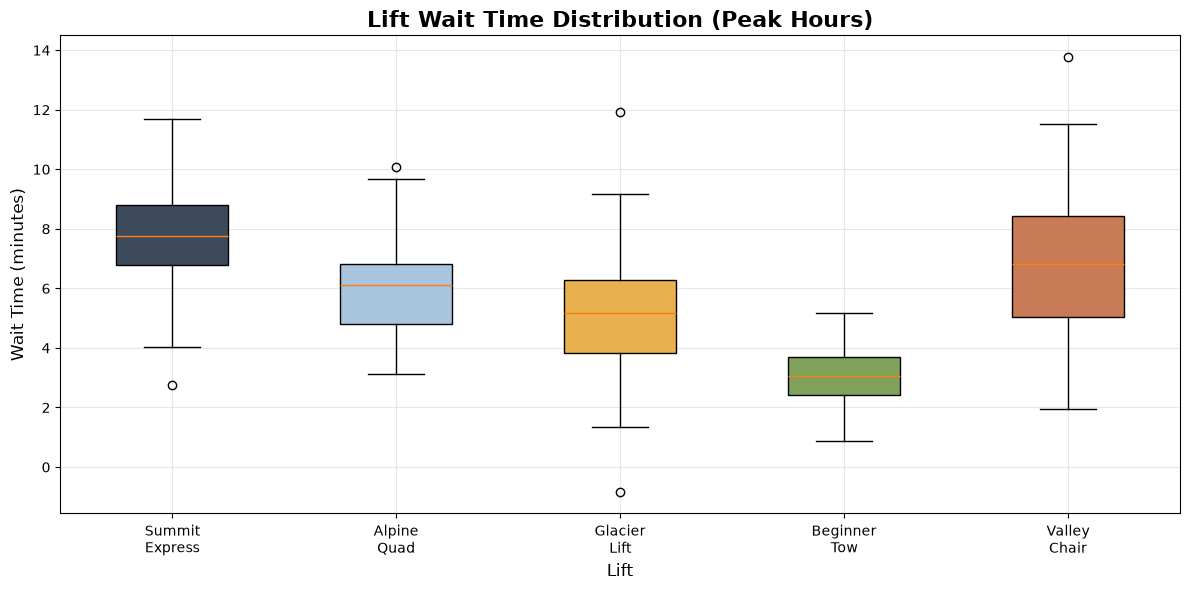

In [54]:
# 1.
lift_order = ["Summit Express", "Alpine Quad", "Glacier Lift", "Beginner Tow", "Valley Chair"]

# 2. 
all_wait_times = []
for lift_name in lift_order:
    lift_rows = waits_df[waits_df["lift_name"] == lift_name]
    all_wait_times.append(lift_rows["wait_minutes"].values)

# 3.
lift_labels = ["Summit\nExpress", "Alpine\nQuad", "Glacier\nLift", "Beginner\nTow", "Valley\nChair"]

# 4
plt.figure(figsize=(12, 6))

# 5
box_plot = plt.boxplot(
    all_wait_times,
    tick_labels=lift_labels,
    patch_artist=True,
)

# 6
box_colors = ["#3D4A5C", "#A8C5DD", "#E8B04E", "#7FA15A", "#C97A57"]

# 7
for box, color in zip(box_plot["boxes"], box_colors):
    box.set_facecolor(color)

# 8
plt.title("Lift Wait Time Distribution (Peak Hours)", fontsize=16, fontweight="bold")

# 9
plt.xlabel("Lift", fontsize=12)
plt.ylabel("Wait Time (minutes)", fontsize=12)

# 10
plt.tight_layout()
plt.show()


## Task 6: Test if snowfall drives attendance with a scatter plot

The marketing team claims that heavy snow brings more visitors the next day. They want to run weather-based ad campaigns. Operations wants proof before spending money.

A **scatter plot** shows the relationship between two numeric variables. Each point is one day. If the points trend upward, the two variables move together. Add a regression line to make the trend explicit and quantify it.

The daily dataset already pairs each day's `snowfall_cm` with the matching `next_day_visitors`. You can plot one against the other directly.

### Instructions

In the next code cell:

1. Pull the two columns out of `daily_df` as plain NumPy arrays (using `.values`):
   - `snowfall = daily_df["snowfall_cm"].values`
   - `next_day_visitors = daily_df["next_day_visitors"].values`

2. Fit a straight line to the data with NumPy:
   - Call `np.polyfit(snowfall, next_day_visitors, deg=1)`. This returns an array of two numbers: the slope and the intercept of the best-fit line. Store it in `slope_and_intercept`.
   - Wrap that array in `np.poly1d(...)` to get a callable function that evaluates the line at any x-value. Store it in `trend_function`.

3. Compute the points on the trend line, sorted by x so the line draws cleanly:
   - `sorted_snowfall = np.sort(snowfall)`
   - `trend_values = trend_function(sorted_snowfall)`

4. Build a label string for the legend that shows the equation of the line:
   ```python
   slope = slope_and_intercept[0]
   intercept = slope_and_intercept[1]
   trend_label = f"Trend: y = {slope:.1f}x + {intercept:.0f}"
   ```

5. Open a new figure with `plt.figure(figsize=(10, 6))`.

6. Draw the scatter plot with `plt.scatter(...)`:
   - x: `snowfall`. y: `next_day_visitors`.
   - `alpha=0.6` so overlapping points are visible.
   - `s=80` to make the dots large enough to read.
   - `color="#3D4A5C"` and `edgecolor="black"`.

7. Draw the trend line on top with `plt.plot(...)`:
   - x: `sorted_snowfall`. y: `trend_values`.
   - `color="red"`, `linestyle="--"`, `linewidth=2`.
   - `label=trend_label`.

8. Add a title `"Fresh Snowfall Impact on Visitor Attendance"` with `fontsize=16` and `fontweight="bold"`.

9. Label the x-axis `"Overnight Snowfall (cm)"` and the y-axis `"Next-Day Visitors"`, both with `fontsize=12`.

10. Call `plt.legend()`, then `plt.tight_layout()` and `plt.show()`.


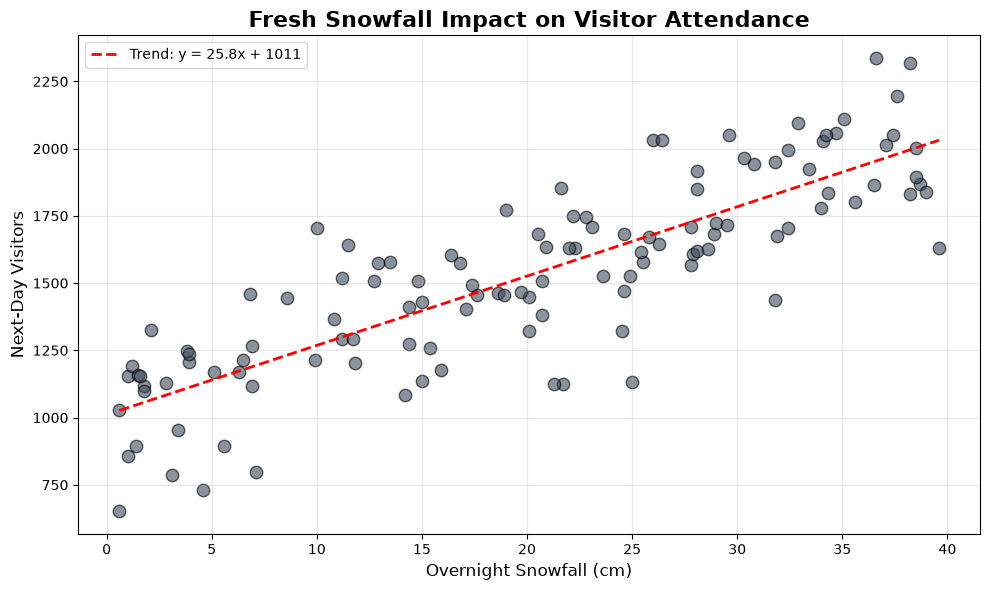

In [55]:
# your code here
import numpy as np
import matplotlib.pyplot as plt

# 1. Extraction des colonnes en arrays NumPy
snowfall = daily_df["snowfall_cm"].values
next_day_visitors = daily_df["next_day_visitors"].values

# 2. Ajustement de la droite de régression
slope_and_intercept = np.polyfit(snowfall, next_day_visitors, deg=1)
trend_function = np.poly1d(slope_and_intercept)

# 3. Points de la droite, triés par x
sorted_snowfall = np.sort(snowfall)
trend_values = trend_function(sorted_snowfall)

# 4. Label de la légende avec l'équation
slope = slope_and_intercept[0]
intercept = slope_and_intercept[1]
trend_label = f"Trend: y = {slope:.1f}x + {intercept:.0f}"

# 5. Nouvelle figure
plt.figure(figsize=(10, 6))

# 6. Nuage de points
plt.scatter(
    snowfall,
    next_day_visitors,
    alpha=0.6,
    s=80,
    color="#3D4A5C",
    edgecolor="black",
)

# 7. Droite de tendance
plt.plot(
    sorted_snowfall,
    trend_values,
    color="red",
    linestyle="--",
    linewidth=2,
    label=trend_label,
)

# 8. Titre
plt.title("Fresh Snowfall Impact on Visitor Attendance", fontsize=16, fontweight="bold")

# 9. Labels des axes
plt.xlabel("Overnight Snowfall (cm)", fontsize=12)
plt.ylabel("Next-Day Visitors", fontsize=12)

# 10. Légende + finalisation
plt.legend()
plt.tight_layout()
plt.show()

## Task 7: Build a one-page dashboard

The general manager wants the four most important charts on a single page. This is a real workplace skill: stakeholders rarely scroll through six separate charts. They want one view that answers the main questions in seconds.

You use **`plt.subplots`** with two rows and two columns. Each grid cell holds one chart. A global title explains what the dashboard covers. The data already loaded at the top of the notebook plugs in directly.

### Instructions

In the next code cell, combine four of the charts you already built into one 2×2 figure. **Reuse the variables from the previous tasks** (`sorted_lifts`, `bar_colors`, `slice_colors`, `explode_settings`, `mean_temperature`), do not recompute them.

1. Create the figure and grid of axes:
   - Call `plt.subplots(nrows=2, ncols=2, figsize=(14, 10))`.
   - Unpack the result into two variables: `fig, axes = ...`. Here `axes` is a 2D NumPy array of Axes objects, indexed `axes[row, col]`.

2. Add a global title for the whole dashboard with `fig.suptitle("AlpineTrack Operations Dashboard - Season 2024", fontsize=18, fontweight="bold")`.

3. **Top-left cell** (`axes[0, 0]`), daily visitors line plot. Assign `top_left = axes[0, 0]`, then:
   - `top_left.plot(daily_df["date"], daily_df["visitors"], color="steelblue", linewidth=1.2)`.
   - `top_left.set_title("Daily Visitors", fontsize=13, fontweight="bold")`.
   - `top_left.set_xlabel("Date")` and `top_left.set_ylabel("Visitors")`.
   - Rotate the x-tick labels 45 degrees with `top_left.tick_params(axis="x", rotation=45)`.

4. **Top-right cell** (`axes[0, 1]`), horizontal bar chart of lift usage. Assign `top_right = axes[0, 1]`, then:
   - `top_right.barh(sorted_lifts["lift_name"], sorted_lifts["total_passengers"], color=bar_colors)`.
   - `top_right.set_title("Total Passengers by Lift", fontsize=13, fontweight="bold")`.
   - `top_right.set_xlabel("Total Passengers")`.

5. **Bottom-left cell** (`axes[1, 0]`), revenue pie chart. Assign `bottom_left = axes[1, 0]`, then call `bottom_left.pie(...)` with the same arguments you used in Task 3 (values, `labels`, `autopct="%1.1f%%"`, `startangle=90`, `colors=slice_colors`, `explode=explode_settings`). Add the title `"Revenue Distribution"` with `fontsize=13` and `fontweight="bold"`.

6. **Bottom-right cell** (`axes[1, 1]`), temperature histogram with mean line. Assign `bottom_right = axes[1, 1]`, then:
   - `bottom_right.hist(daily_df["temperature_celsius"], bins=25, color="#A8C5DD", alpha=0.8, edgecolor="black")`.
   - Build a short label: `mean_label = f"Mean = {mean_temperature:.1f} C"`.
   - `bottom_right.axvline(mean_temperature, color="red", linestyle="--", linewidth=2, label=mean_label)`.
   - Set the title `"Daily High Temperature"` with `fontsize=13` and `fontweight="bold"`.
   - Set the x-label `"Temperature (degrees C)"` and the y-label `"Number of Days"`.
   - Call `bottom_right.legend()`.

7. Call `plt.tight_layout(rect=[0, 0, 1, 0.96])`. The `rect` argument leaves a strip of space at the top of the figure for the global title so it does not overlap the subplots.

8. Call `plt.show()`.

<Note type='tip'>
**Method names change with subplots.** When you draw on an Axes object (not on `plt`), the methods are slightly different: `set_title` instead of `title`, `set_xlabel` instead of `xlabel`, `set_ylabel` instead of `ylabel`, `tick_params` instead of `xticks`. The arguments inside are the same.
</Note>


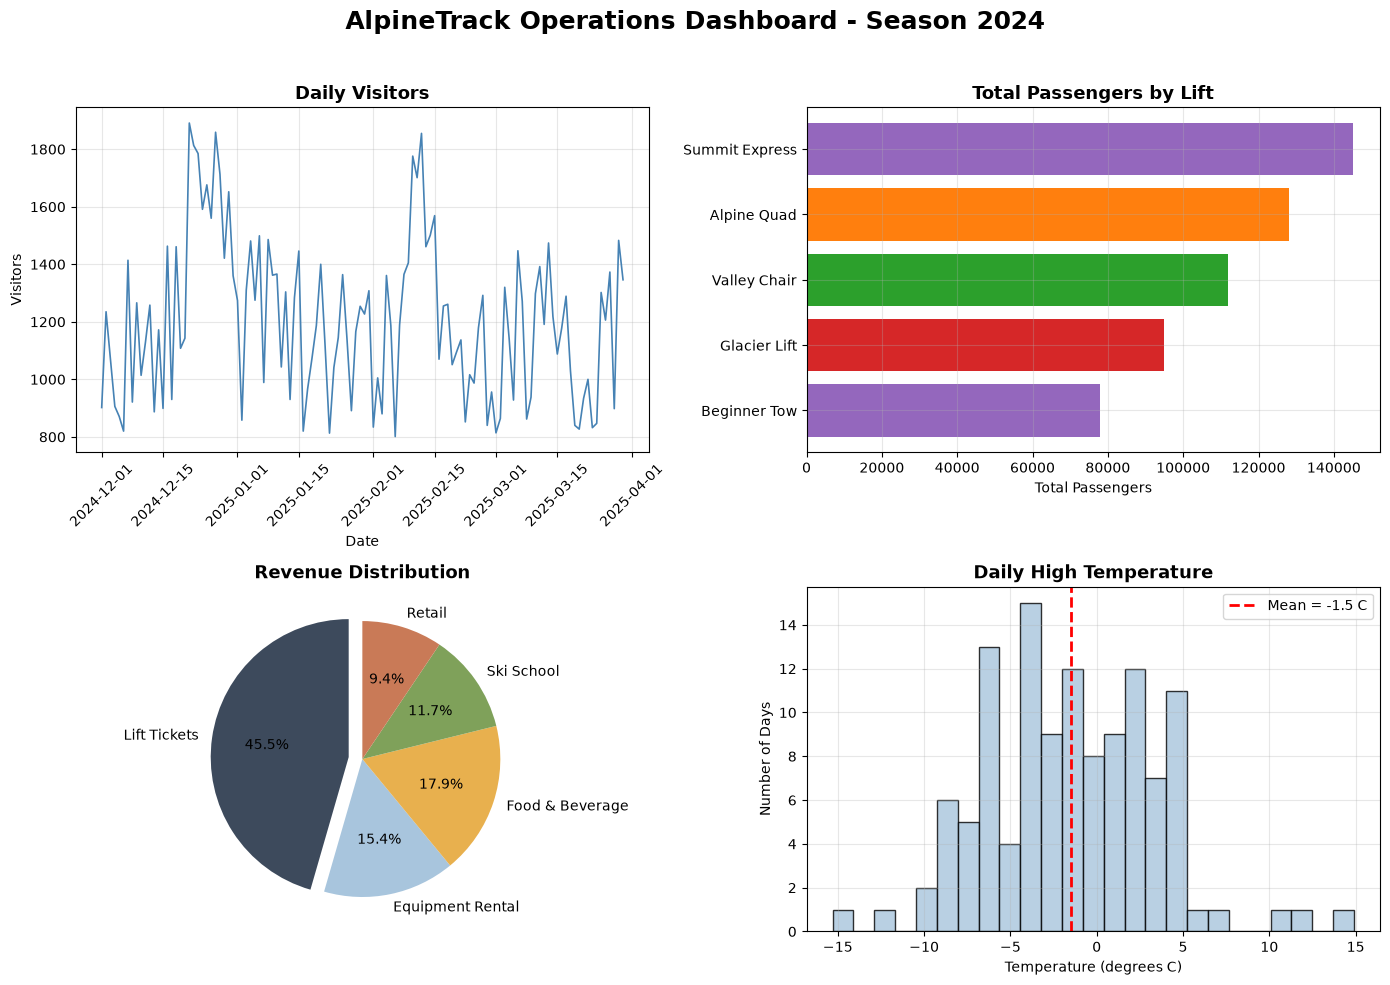

In [57]:
# your code here
import matplotlib.pyplot as plt

# 1. Grille 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# 2. Titre global
fig.suptitle("AlpineTrack Operations Dashboard - Season 2024", fontsize=18, fontweight="bold")

# 3. Haut-gauche : visiteurs quotidiens
top_left = axes[0, 0]
top_left.plot(daily_df["date"], daily_df["visitors"], color="steelblue", linewidth=1.2)
top_left.set_title("Daily Visitors", fontsize=13, fontweight="bold")
top_left.set_xlabel("Date")
top_left.set_ylabel("Visitors")
top_left.tick_params(axis="x", rotation=45)

# 4. Haut-droite : barres horizontales fréquentation remontées
top_right = axes[0, 1]
top_right.barh(sorted_lifts_df["lift_name"], sorted_lifts_df["total_passengers"], color=bar_colors)
top_right.set_title("Total Passengers by Lift", fontsize=13, fontweight="bold")
top_right.set_xlabel("Total Passengers")

# 5. Bas-gauche : diagramme circulaire des revenus
bottom_left = axes[1, 0]
bottom_left.pie(
    revenue_df["amount_eur"],
    labels=revenue_df["source"],
    autopct="%1.1f%%",
    startangle=90,
    colors=slice_colors,
    explode=explode_settings,
)
bottom_left.set_title("Revenue Distribution", fontsize=13, fontweight="bold")

# 6. Bas-droite : histogramme des températures avec ligne de moyenne
bottom_right = axes[1, 1]
bottom_right.hist(daily_df["temperature_celsius"], bins=25, color="#A8C5DD", alpha=0.8, edgecolor="black")
mean_label = f"Mean = {mean_temperature:.1f} C"
bottom_right.axvline(mean_temperature, color="red", linestyle="--", linewidth=2, label=mean_label)
bottom_right.set_title("Daily High Temperature", fontsize=13, fontweight="bold")
bottom_right.set_xlabel("Temperature (degrees C)")
bottom_right.set_ylabel("Number of Days")
bottom_right.legend()

# 7. Ajustement avec espace pour le titre global
plt.tight_layout(rect=[0, 0, 1, 0.96])

# 8. Affichage
plt.show()



To save the dashboard for a presentation, add this line right after `plt.show()`:

```python
plt.savefig("alpinetrack_dashboard.png", dpi=300, bbox_inches="tight")
```

The `dpi=300` setting makes the image sharp enough for print. The `bbox_inches="tight"` setting trims white space around the edges so the image fits cleanly in slides.